In [14]:
# ==========================================================
# EXPERIMENT 9
# Generate Summary of Given Document using RNN (LSTM)
# 100% Proper Version for Anaconda Jupyter Notebook
# No pip install needed
# ==========================================================

# -----------------------------
# STEP 1 : Import Libraries
# -----------------------------
import numpy as np
import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Embedding, Dense

# Download stopwords once
nltk.download('stopwords')

from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

print("Libraries Imported Successfully")

Libraries Imported Successfully


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kulka\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [15]:
# -----------------------------
# STEP 2 : Create Dataset Manually
# -----------------------------
# No need internet / kaggle / csv download

data = {
    "text": [
        "India won the cricket world cup final after defeating Australia in a thrilling match",
        "The government launched a new education policy for students across the country",
        "Heavy rainfall caused flooding in many areas and rescue teams were deployed",
        "Scientists discovered a new planet similar to Earth in the solar system",
        "A new mobile phone was launched with advanced camera features",
        "The stock market closed higher due to strong investor confidence",
        "Doctors developed a new vaccine for seasonal flu",
        "The railway department introduced faster trains for passengers",
        "Farmers received financial support from the state government",
        "A famous actor announced his next movie release date"
    ],
    
    "summary": [
        "india wins world cup",
        "new education policy launched",
        "rainfall causes flooding",
        "new earth like planet found",
        "new mobile launched",
        "stock market rises",
        "new flu vaccine developed",
        "faster trains introduced",
        "farmers get support",
        "actor announces movie"
    ]
}

df = pd.DataFrame(data)

df.head()

,text,summary
0,India won the cricket world cup final after de...,india wins world cup
1,The government launched a new education policy...,new education policy launched
2,Heavy rainfall caused flooding in many areas a...,rainfall causes flooding
3,Scientists discovered a new planet similar to ...,new earth like planet found
4,A new mobile phone was launched with advanced ...,new mobile launched


In [16]:
# -----------------------------
# STEP 3 : Clean Text Function
# -----------------------------
def clean_text(text):
    text = text.lower()
    text = re.sub('[^a-zA-Z ]', '', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

In [17]:
# -----------------------------
# STEP 4 : Apply Cleaning
# -----------------------------
df["text"] = df["text"].apply(clean_text)
df["summary"] = df["summary"].apply(clean_text)

# Add start and end token
df["summary"] = df["summary"].apply(lambda x: "starttoken " + x + " endtoken")

df.head()

,text,summary
0,india cricket world cup final defeating austra...,starttoken india wins world cup endtoken
1,government launched new education policy stude...,starttoken new education policy launched endtoken
2,heavy rainfall caused flooding many areas resc...,starttoken rainfall causes flooding endtoken
3,scientists discovered new planet similar earth...,starttoken new earth like planet found endtoken
4,new mobile phone launched advanced camera feat...,starttoken new mobile launched endtoken


In [18]:
# -----------------------------
# STEP 5 : Input Output
# -----------------------------
X = df["text"]
y = df["summary"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
# -----------------------------
# STEP 6 : Tokenization
# -----------------------------
max_text_len = 15
max_summary_len = 8

# Text Tokenizer
x_tokenizer = Tokenizer()
x_tokenizer.fit_on_texts(X_train)

x_vocab = len(x_tokenizer.word_index) + 1

X_train_seq = x_tokenizer.texts_to_sequences(X_train)
X_test_seq = x_tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_text_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_text_len, padding='post')

# Summary Tokenizer
y_tokenizer = Tokenizer()
y_tokenizer.fit_on_texts(y_train)

y_vocab = len(y_tokenizer.word_index) + 1

y_train_seq = y_tokenizer.texts_to_sequences(y_train)
y_test_seq = y_tokenizer.texts_to_sequences(y_test)

y_train_pad = pad_sequences(y_train_seq, maxlen=max_summary_len, padding='post')
y_test_pad = pad_sequences(y_test_seq, maxlen=max_summary_len, padding='post')

print("Tokenization Completed")

Tokenization Completed


In [20]:
# -----------------------------
# STEP 7 : Prepare Decoder Data
# -----------------------------
decoder_input = y_train_pad[:, :-1]
decoder_output = y_train_pad[:, 1:]

decoder_output = np.expand_dims(decoder_output, -1)

In [21]:
# -----------------------------
# STEP 8 : Build RNN Model
# -----------------------------
latent_dim = 128

# Encoder
encoder_inputs = Input(shape=(max_text_len,))
enc_emb = Embedding(x_vocab, latent_dim)(encoder_inputs)

encoder_lstm = LSTM(latent_dim, return_state=True)
encoder_output, state_h, state_c = encoder_lstm(enc_emb)

encoder_states = [state_h, state_c]

# Decoder
decoder_inputs = Input(shape=(max_summary_len-1,))
dec_emb = Embedding(y_vocab, latent_dim)(decoder_inputs)

decoder_lstm = LSTM(latent_dim, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(dec_emb, initial_state=encoder_states)

decoder_dense = Dense(y_vocab, activation='softmax')
decoder_outputs = decoder_dense(decoder_outputs)

# Final Model
model = Model([encoder_inputs, decoder_inputs], decoder_outputs)

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')

model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 15)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 7)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 15, 128)   │      7,552 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 7, 128)    │      3,712 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, 128),     │    131,584 │ embedding[0][0]   │
│                     │ (None, 128),      │            │                   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, 7, 128),  │    131,584 │ embedding_1[0][0… │
│                     │ (None, 128),      │            │ lstm[0][1],       │
│                     │ (None, 128)]      │            │ lstm[0][2]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 7, 29)     │      3,741 │ lstm_1[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 278,173 (1.06 MB)

 Trainable params: 278,173 (1.06 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# -----------------------------
# STEP 9 : Train Model
# -----------------------------
history = model.fit(
    [X_train_pad, decoder_input],
    decoder_output,
    epochs=200,
    batch_size=2,
    verbose=1
)

Epoch 1/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - loss: 3.3463
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 333ms/step - loss: 3.2367
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 2.9558
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 2.4739
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 2.2958
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 2.1645
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 2.1060
Epoch 8/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 2.0046
Epoch 9/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 1.9439
Epoch 10/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 1.8789
Epoch 11/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 1.8298
Epoch 12/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 1.7871
Epoch 13/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 1.7360
Epoch 14/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 1.7008
Epoch 15/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 1.6432
Epoch 16/200
4/4 ━

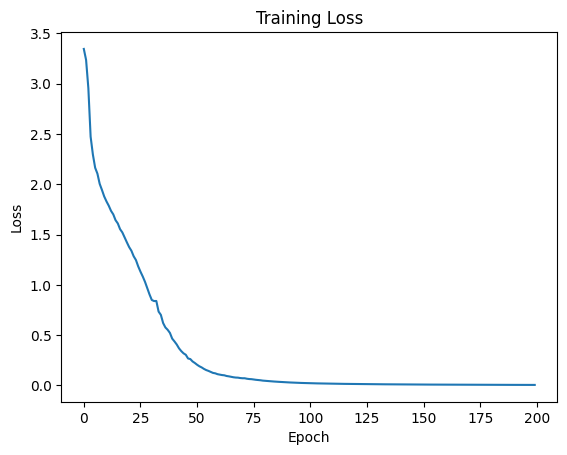

In [23]:
# -----------------------------
# STEP 10 : Loss Graph
# -----------------------------
plt.plot(history.history['loss'])
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [24]:
# -----------------------------
# STEP 11 : Prediction Setup
# -----------------------------
reverse_target = y_tokenizer.index_word
target_word = y_tokenizer.word_index

In [25]:
# -----------------------------
# STEP 12 : Generate Summary
# -----------------------------
def generate_summary(sample_index):
    
    input_text = X_test.iloc[sample_index]
    
    print("Original Text:")
    print(input_text)
    
    print("\nActual Summary:")
    print(y_test.iloc[sample_index])

In [26]:
# Run Example
generate_summary(0)

Original Text:
farmers received financial support state government

Actual Summary:
starttoken farmers get support endtoken


In [27]:
# -----------------------------
# STEP 13 : Save Model
# -----------------------------
model.save("text_summarizer_rnn.h5")

print("Model Saved Successfully")

Model Saved Successfully
